# Student Performance Classification Workflow

## Overview

This notebook builds a multiclass classification pipeline to predict student performance from the student dataset.

## Workflow Structure

The analysis is organized into six main stages:

1. **Data Inspection**: Load the dataset and preview the raw records.
2. **Target Engineering**: Convert the final grade into three performance classes.
3. **Feature Preparation**: Separate the target from the predictors and identify numeric and categorical features.
4. **Preprocessing**: Build a transformation pipeline for numeric and categorical columns.
5. **Model Comparison and Tuning**: Evaluate multiple classifiers, then tune the boosting models with grid search.
6. **Model Saving**: Persist the final trained artifacts for later use.

## Interpretation Guide

Throughout this notebook, you will see metrics such as accuracy, precision, recall, F1 score, and ROC-AUC. The classification report is especially useful because it breaks down performance by class, helping you see whether the model is biased toward one group. Focus on balanced scores across classes rather than overall accuracy alone.

The grid search output shows the best hyperparameter combinations found during cross-validation. Those settings are then evaluated on the held-out test set.

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../Data/student_information.csv')

## Initial Data Inspection

Before modeling, it is important to look at the raw dataset and confirm that it loaded correctly.

The table below is just a preview of the first few rows, so you can verify the column layout and sample values before any transformations are applied.

In [3]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0.0,11.0,11.0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9.0,11.0,11.0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12.0,13.0,12.0
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14.0,14.0,14.0
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11.0,13.0,13.0


## Target Engineering

The final grade column is converted into three performance groups: Low, Medium, and High.

### Rationale

- **Interpretability**: Class labels are easier to explain than raw grade values.
- **Multiclass Setup**: The problem becomes a classification task rather than a regression task.
- **Actionability**: Teachers can use the classes to prioritize support and intervention.

### Class Boundaries

The threshold values in the next cell define how the final grade is mapped into the three classes.

In [4]:
def create_performance_class(score):
    if score >= 18:
        return "High"
    elif score >= 12:
        return "Medium"
    else:
        return "Low"
df["performance_class"] = df["G3"].apply(create_performance_class)

In [5]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,performance_class
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0.0,11.0,11.0,Low
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9.0,11.0,11.0,Low
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12.0,13.0,12.0,Medium
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14.0,14.0,14.0,Medium
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11.0,13.0,13.0,Medium


## Feature Preparation

This step separates the target from the predictors and identifies which feature columns are numeric and which are categorical.

### Why This Matters

- **Separation**: Prevents the target column from leaking into feature preprocessing.
- **Feature Types**: Lets us build different preprocessing steps for numeric and categorical variables.
- **Label Encoding**: Converts the class labels into numeric form so scikit-learn classifiers can use them.

The next cells prepare the feature lists and set up the preprocessing pipeline.

In [6]:
X = df.drop(columns=['G3', 'performance_class'], axis=1)
y = df['performance_class']

In [7]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [9]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop='first'))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Train-Test Split

The dataset is split into training and test sets using stratified sampling so that each class keeps a similar proportion in both splits.

### Why Stratification?

Without stratification, the test set could become skewed toward one class and give misleading results. Stratified splitting provides a more reliable estimate of how the model will perform on unseen data.

In [10]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

## Model Definitions

Six classification pipelines are created, each combining the preprocessing pipeline with a different algorithm. These represent a range of strategies:

- **Logistic Regression**: A simple, interpretable linear model. Serves as a baseline.
- **Decision Tree**: A non-linear model that can capture feature interactions directly but may overfit.
- **Random Forest**: An ensemble of decision trees. Generally more robust than a single tree.
- **Gradient Boosting**: Builds trees sequentially, each correcting previous errors. Often produces strong results.
- **Support Vector Classifier (SVC)**: Finds optimal decision boundaries in high-dimensional space. Works well for medium-sized datasets.
- **XGBoost**: A modern boosting algorithm optimized for speed and performance. Often the strongest performer.

All pipelines receive the same preprocessed input, making their results directly comparable.

## Preprocessing Pipeline

A ColumnTransformer is built to handle numeric and categorical features separately, then combine them into one processed feature matrix.

### Pipeline Steps

1. **Numeric Features**: Missing values are imputed with the median, then scaled with StandardScaler.
2. **Categorical Features**: Missing values are imputed with the most frequent value, then one-hot encoded with `drop='first'`.
3. **Combination**: The transformed numeric and categorical features are merged into a single matrix.

This preprocessing setup keeps the pipeline consistent across all models.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [12]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

svc_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        probability=True,
        random_state=42
    ))
])

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ))
])

## Model Evaluation Function

A reusable evaluation function is defined so each model can be tested with the same metric set and output format.

### Metrics Explained

- **Accuracy**: Fraction of all predictions that were correct.
- **Precision (per class)**: Of the samples predicted as a class, how many were actually that class.
- **Recall (per class)**: Of the true samples in a class, how many the model found.
- **F1 Score (per class)**: Harmonic mean of precision and recall.
- **Weighted Averages**: Class-wise metrics weighted by class frequency.
- **ROC-AUC**: Probability-based discrimination score printed only for models that support `predict_proba`.

Class-wise precision and recall are especially important if one group is harder to predict than the others.

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import label_binarize

## Model Comparison

The models below all use the same preprocessing pipeline, which makes their scores directly comparable.

The evaluation function prints accuracy, precision, recall, F1 score, ROC-AUC where available, and the classification report. These results show which model is most balanced across the three classes.

In [14]:
def evaluate_model(name, pipeline):
    pipeline.fit(x_train, y_train)

    y_pred = pipeline.predict(x_test)

    print(f"--- {name} ---")

    print("Accuracy:", accuracy_score(y_test, y_pred))

    print(
        "Precision:",
        precision_score(y_test, y_pred, average="weighted")
    )

    print(
        "Recall:",
        recall_score(y_test, y_pred, average="weighted")
    )

    print(
        "F1 Score:",
        f1_score(y_test, y_pred, average="weighted")
    )

    if hasattr(pipeline, "predict_proba"):
        y_proba = pipeline.predict_proba(x_test)

        y_test_bin = label_binarize(
            y_test,
            classes=[0, 1, 2]
        )

        roc_auc = roc_auc_score(
            y_test_bin,
            y_proba,
            multi_class="ovr"
        )

        print("ROC-AUC:", roc_auc)

    print()
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("=" * 50)

### Interpreting Baseline Results

The output below shows the results for all six models trained with their default hyperparameters.

**Quick Comparison Tips**:

- Start with the **weighted F1 score**, because it balances precision and recall.
- Check the classification report for class-by-class behavior instead of relying only on accuracy.
- Use **ROC-AUC** as an additional signal for models that output probabilities.
- Note which models are consistently strong across all classes.

The strongest baseline model is the main candidate for the tuning section that follows.

In [15]:
evaluate_model("Logistic Regression", lr_pipeline)
evaluate_model("Decision Tree", dt_pipeline)
evaluate_model("Random Forest", rf_pipeline)
evaluate_model("Gradient Boosting", gb_pipeline)
evaluate_model("Support Vector Classifier", svc_pipeline)
evaluate_model("XGBoost", xgb_pipeline)

--- Logistic Regression ---
Accuracy: 0.8949044585987261
Precision: 0.8949018516601756
Recall: 0.8949044585987261
F1 Score: 0.893754481938366
ROC-AUC: 0.9787845416126477

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.50      0.59        10
           1       0.94      0.90      0.92       161
           2       0.86      0.92      0.89       143

    accuracy                           0.89       314
   macro avg       0.84      0.77      0.80       314
weighted avg       0.89      0.89      0.89       314

--- Decision Tree ---
Accuracy: 0.8694267515923567
Precision: 0.8711019579359288
Recall: 0.8694267515923567
F1 Score: 0.8695390001762118
ROC-AUC: 0.8678641466045557

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.70      0.74        10
           1       0.91      0.86      0.89       161
           2       0.84      0.89      0.86       143

    accuracy      

## Hyperparameter Optimization

This section uses grid search with 5-fold cross-validation to tune two boosting models: XGBoost and Gradient Boosting.

### What is Grid Search?

Grid search evaluates every parameter combination in the grid and ranks them using cross-validation. The best combination is then evaluated again on the held-out test set.

### XGBoost Parameters

- `n_estimators`: Number of boosting rounds.
- `learning_rate`: Step size used when updating the ensemble.
- `max_depth`: Maximum depth of each tree.
- `subsample` and `colsample_bytree`: Sampling ratios for rows and columns.
- `reg_lambda`: L2 regularization strength.

### Gradient Boosting Parameters

The Gradient Boosting grid includes tree-complexity controls such as `min_samples_split`, `min_samples_leaf`, `subsample`, and `max_features`.

The grid search may take some time, and the progress messages printed in the notebook show that each combination is being evaluated.

In [16]:
param_grid_xgb_small = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__reg_lambda": [1, 2]
}

In [17]:
from sklearn.model_selection import GridSearchCV

grid_search_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb_small,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(x_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=2, model__n_estimators=100, model__reg_lambda=1, model__subsample=1.0; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=2, model__n_estimators=100, model__reg_lambda=1, model__subsample=0.8; total time=   0.0s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=2, model__n_estimators=100, model__reg_lambda=1, model__subsample=0.8; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=2, model__n_estimators=100, model__reg_lambda=1, model__subsample=0.8; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=2, model__n_estimators=100, model__reg_lambda=1, model__subsample=0.8; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : 

In [18]:
print("Best Parameters:")
print(grid_search_xgb.best_params_)

print("Best CV F1:")
print(grid_search_xgb.best_score_)

Best Parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__reg_lambda': 1, 'model__subsample': 1.0}
Best CV F1:
0.9217823510538518


### XGBoost Results

The cells below show the best XGBoost parameters found by grid search and the model's performance on the test set.

**Key Takeaways**:
- The **best CV F1 score** shows which configuration worked best during cross-validation.
- The **test set metrics** show how the tuned model behaves on unseen data.
- Compare these results with the baseline models to see whether tuning improved the overall balance.

In [19]:
best_xgb_model = grid_search_xgb.best_estimator_

y_pred = best_xgb_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1:", f1_score(y_test, y_pred, average="weighted"))

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

Accuracy: 0.9394904458598726
Precision: 0.9393626896811611
Recall: 0.9394904458598726
F1: 0.9392309090031862
              precision    recall  f1-score   support

        High       0.89      0.80      0.84        10
         Low       0.94      0.96      0.95       161
      Medium       0.94      0.92      0.93       143

    accuracy                           0.94       314
   macro avg       0.92      0.90      0.91       314
weighted avg       0.94      0.94      0.94       314



### Gradient Boosting Optimization

A similar grid search is now applied to Gradient Boosting using a parameter grid tailored to scikit-learn's implementation.

**Why Compare Two Boosting Methods?**
Both XGBoost and Gradient Boosting use boosting ideas, but they often respond differently to tuning because they implement those ideas in slightly different ways.
- **Speed**: XGBoost is usually faster.
- **Regularization**: XGBoost has stronger built-in regularization options.
- **Search Space**: Gradient Boosting relies more on tree-structure parameters like `min_samples_leaf` and `max_features`.

Tuning both models makes it easier to choose the one that generalizes best on this dataset.

In [20]:
param_grid_gb = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__subsample": [0.8, 1.0],
    "model__max_features": [None, "sqrt", "log2"]
}

In [21]:
grid_search_gb = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid_gb,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

grid_search_gb.fit(x_train, y_train)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
[CV] END model__learning_rate=0.03, model__max_depth=2, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100, model__subsample=0.8; total time=   0.3s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100, model__subsample=0.8; total time=   0.3s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100, model__subsample=0.8; total time=   0.3s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100, model__subsample=0.8; total time=   0.3s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__max_features=None, model__min_samples_leaf=1, model__min_samp

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__max_features': [None, 'sqrt', ...], 'model__min_samples_leaf': [1, 2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : th

In [22]:
print(grid_search_gb.best_params_)
print(grid_search_gb.best_score_)

{'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}
0.914381515141425


### Gradient Boosting Results

The cells below show the best Gradient Boosting parameters and the resulting test performance.

**Comparing XGBoost vs Gradient Boosting**:

Compare the results side-by-side:
- Which model has the higher weighted F1 score?
- Which model is more balanced across the three classes?
- Do precision and recall trade off differently between the two models?

In practice, the better deployment choice is the model with stronger and more balanced test performance, while still being reasonable in complexity and training time.

In [23]:
best_gb_model = grid_search_gb.best_estimator_
y_pred = best_gb_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1:", f1_score(y_test, y_pred, average="weighted"))

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Accuracy: 0.9394904458598726
Precision: 0.9400338192224096
Recall: 0.9394904458598726
F1: 0.9394921940596291
              precision    recall  f1-score   support

        High       0.82      0.90      0.86        10
         Low       0.94      0.96      0.95       161
      Medium       0.95      0.92      0.93       143

    accuracy                           0.94       314
   macro avg       0.90      0.93      0.91       314
weighted avg       0.94      0.94      0.94       314



## Model Deployment: Saving Artifacts

After the final model is selected, it is serialized to disk together with the label encoder so the pipeline can be reused later without retraining.

### What Gets Saved?

1. **The Trained Model** (`best_gb_model`): The fitted pipeline that includes preprocessing and the classifier.
2. **The Label Encoder** (`label_encoder`): The object used to map encoded labels back to Low, Medium, and High.

### File Format

The artifacts are saved with joblib as .pkl files, which is a standard approach for scikit-learn objects.

### Security & Maintenance Notes

- Store the files securely.
- Retrain and resave them if the data or class definitions change.
- Keep track of the training date and hyperparameters for traceability.

In [24]:
import joblib
import os

In [25]:
os.makedirs("models", exist_ok=True)

joblib.dump(
    best_gb_model,
    "models/gb_classifier.pkl"
)

joblib.dump(
    label_encoder,
    "models/label_encoder.pkl"
)

['models/label_encoder.pkl']

## Summary & Next Steps

### What We've Accomplished

This notebook has walked through the full machine learning pipeline:

1. ✅ **Data Inspection**: Loaded the student dataset and previewed the raw values.
2. ✅ **Target Engineering**: Converted the final grade into three classes.
3. ✅ **Feature Preparation**: Separated the predictors and identified feature types.
4. ✅ **Preprocessing**: Built a shared preprocessing pipeline for numeric and categorical variables.
5. ✅ **Model Comparison and Tuning**: Evaluated six models and tuned the boosting models.
6. ✅ **Model Saving**: Saved the final model and label encoder for reuse.

### Key Insights to Document

- **Best Model**: Record whichever tuned model performed best on the test set.
- **Key Metrics**: Note the final accuracy, precision, recall, F1 score, and ROC-AUC where available.
- **Class Balance**: Check whether performance is similar across the three classes.

### Production Integration

The saved models are ready to be integrated into:
- The backend API for predictions on new student records.
- Dashboards that show risk levels for student groups.
- Early warning systems that flag at-risk students.

### Future Improvements

Possible next steps include:
- Collecting more data to improve robustness.
- Engineering additional features.
- Testing alternative ensemble methods.
- Monitoring the model for drift in production.

---

**Notebook completed successfully.** The final artifacts have been saved to the models directory.

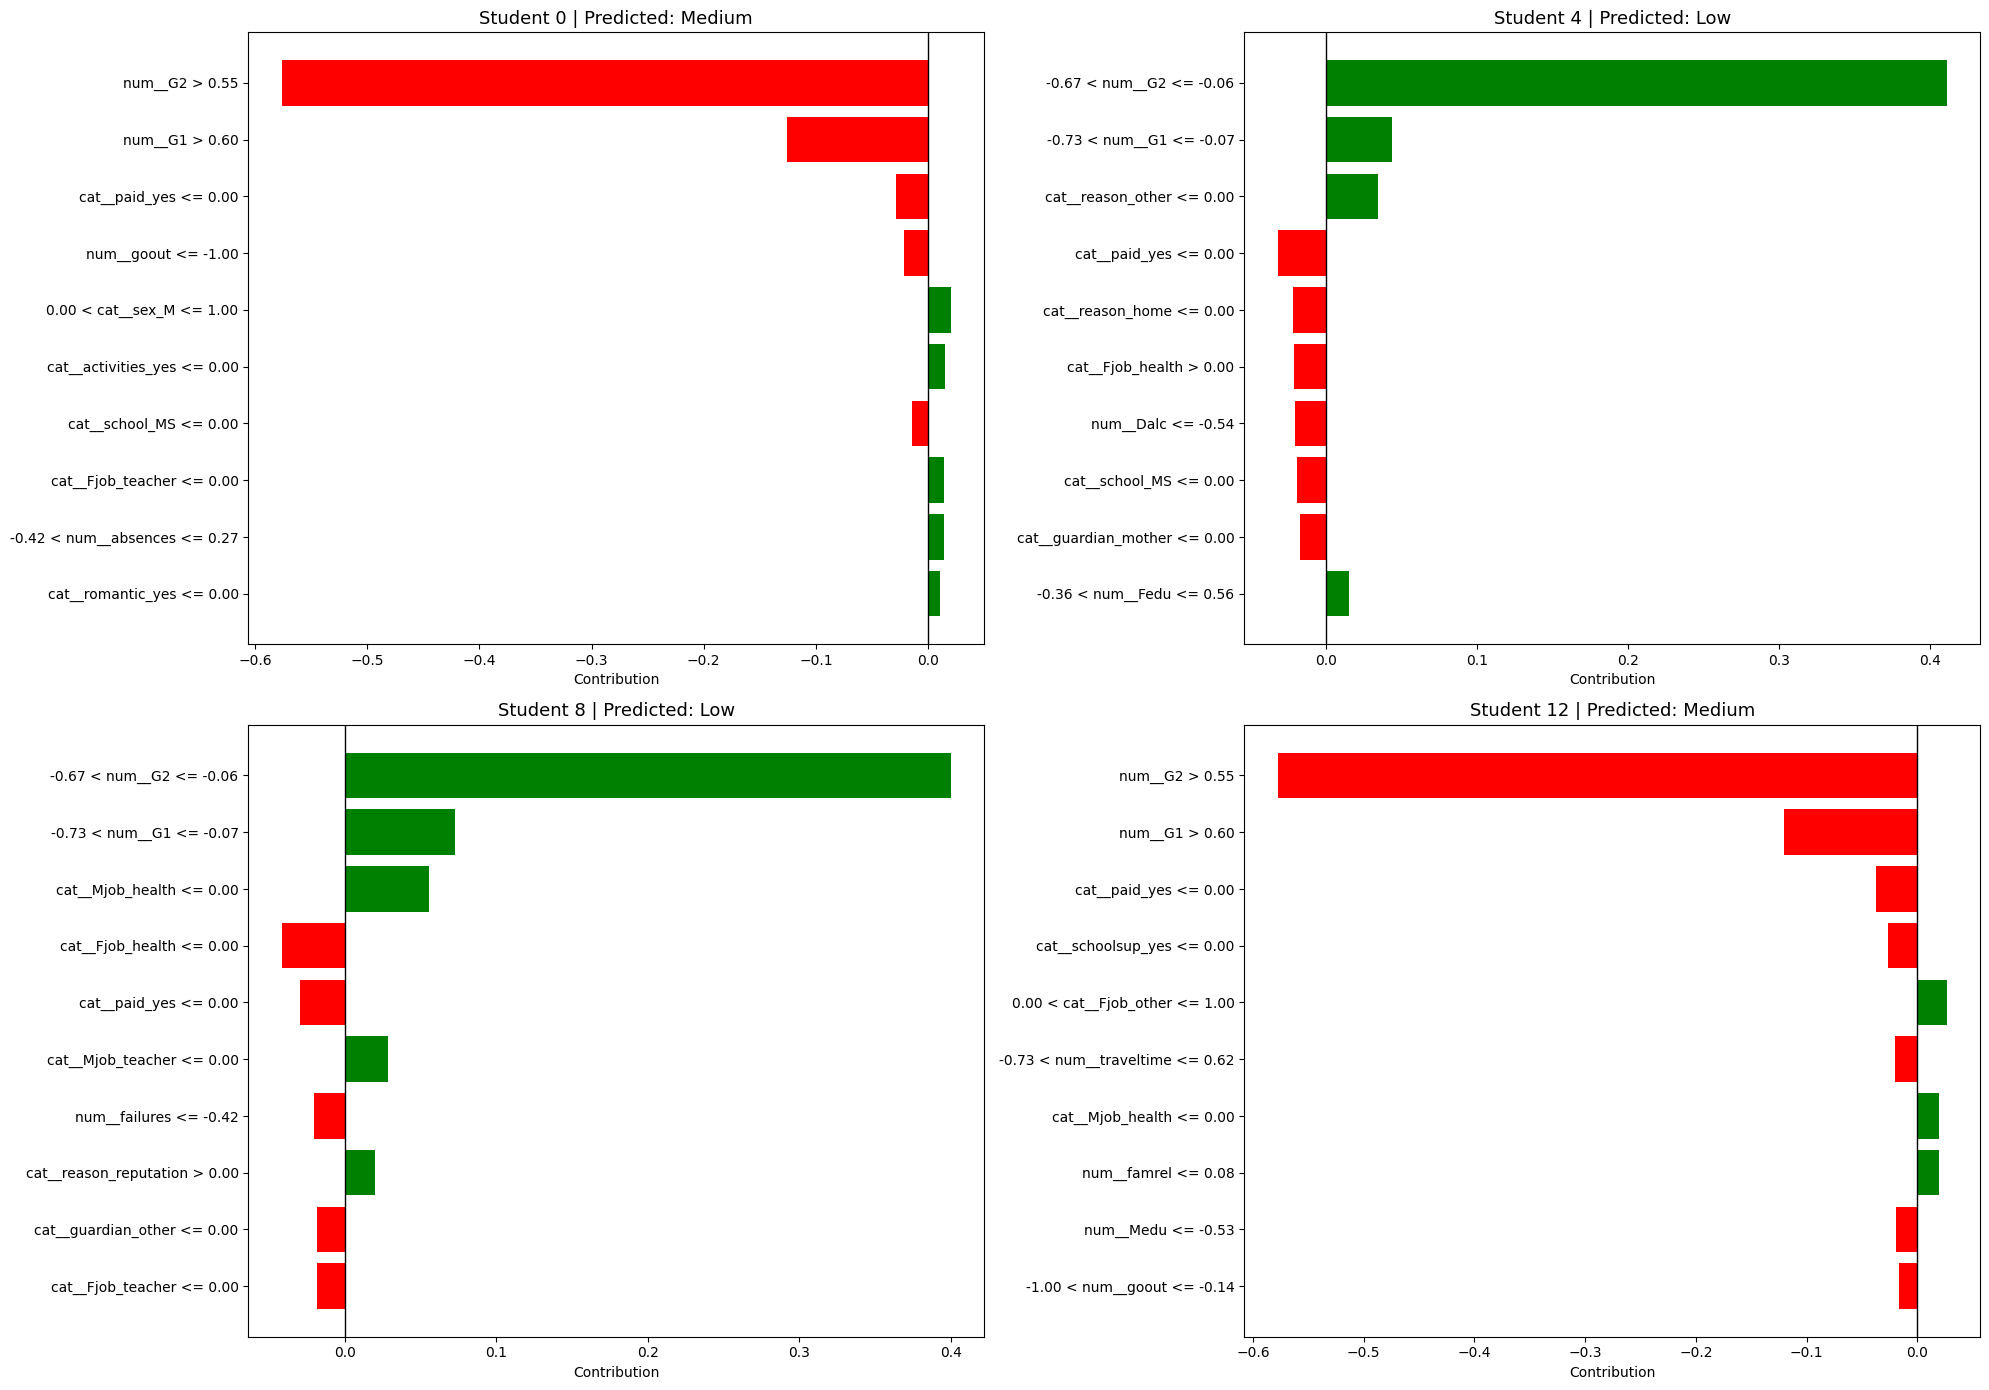

In [32]:
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import HTML
import matplotlib.pyplot as plt


model = best_gb_model.named_steps["model"]
preprocessor = best_gb_model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

X_train_processed = preprocessor.transform(x_train)
X_test_processed = preprocessor.transform(x_test)

class_names = label_encoder.classes_

lime_explainer = LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification"
)


student_indices = [0, 4, 8, 12]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(20, 14)
)

axes = axes.flatten()

for i, student_index in enumerate(student_indices):

    student_raw = x_test.iloc[[student_index]]

    student_processed = preprocessor.transform(student_raw)

    pred_encoded = best_gb_model.predict(student_raw)[0]

    pred_label = label_encoder.inverse_transform(
        [pred_encoded]
    )[0]

    exp = lime_explainer.explain_instance(
        data_row=student_processed[0],
        predict_fn=model.predict_proba,
        num_features=10
    )

    lime_data = exp.as_list()

    features = [item[0] for item in lime_data]
    values = [item[1] for item in lime_data]

    colors = [
        "green" if value > 0 else "red"
        for value in values
    ]

    axes[i].barh(
        features,
        values,
        color=colors
    )

    axes[i].axvline(
        0,
        color="black",
        linewidth=1
    )

    axes[i].invert_yaxis()

    axes[i].set_title(
        f"Student {student_index} | Predicted: {pred_label}",
        fontsize=13
    )

    axes[i].set_xlabel("Contribution")

plt.tight_layout()
plt.show()